
Ollama + RAGAS

C:\Users\Mateusz\AppData\Local\Temp\ipykernel_21092\4125272852.py:11: DeprecationWarning: Importing Faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import Faithfulness
  from ragas.metrics import Faithfulness, AnswerRelevancy, ContextPrecision
C:\Users\Mateusz\AppData\Local\Temp\ipykernel_21092\4125272852.py:11: DeprecationWarning: Importing AnswerRelevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import AnswerRelevancy
  from ragas.metrics import Faithfulness, AnswerRelevancy, ContextPrecision
C:\Users\Mateusz\AppData\Local\Temp\ipykernel_21092\4125272852.py:11: DeprecationWarning: Importing ContextPrecision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections imp

--- Przygotowanie bazy w: ../.././../wektorowa_bazadanych/lokalna ---
Utworzono 591 fragmentów.

🚀 Testowanie zapytania: Jakie ubezpieczenie uczelnia zaleca studentom?
Odpowiedź modelu:  Zabezpieczenie Uczelni przygotuje się do osiągnięcia efektów uczenia się dla przedmiotów badawczych, włączając między innymi:
1. Ocenę końcowe wykorzystywane są przez personne officiatinge lub personel katedry, zgodnie z regulacjami § 20 i § 6.
2. Studentom może się przemianić studium w Uczelnie lub przenieść się do innych institucionalizacji, ograniczając to przy uzyciu określonych procedur oraz programów do rozwinięcia, aby zgodnie się z reglamentem § 7.
Brak informacji w kontekście.

--- Ewaluacja RAGAS ---


Evaluating:   0%|          | 0/3 [00:00<?, ?it/s]

Exception raised in Job[0]: TimeoutError()
Exception raised in Job[1]: TimeoutError()
Exception raised in Job[2]: TimeoutError()


Dostępne kolumny w wynikach: ['user_input', 'retrieved_contexts', 'response', 'reference', 'faithfulness', 'answer_relevancy', 'context_precision', 'tfidf_similarity']


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


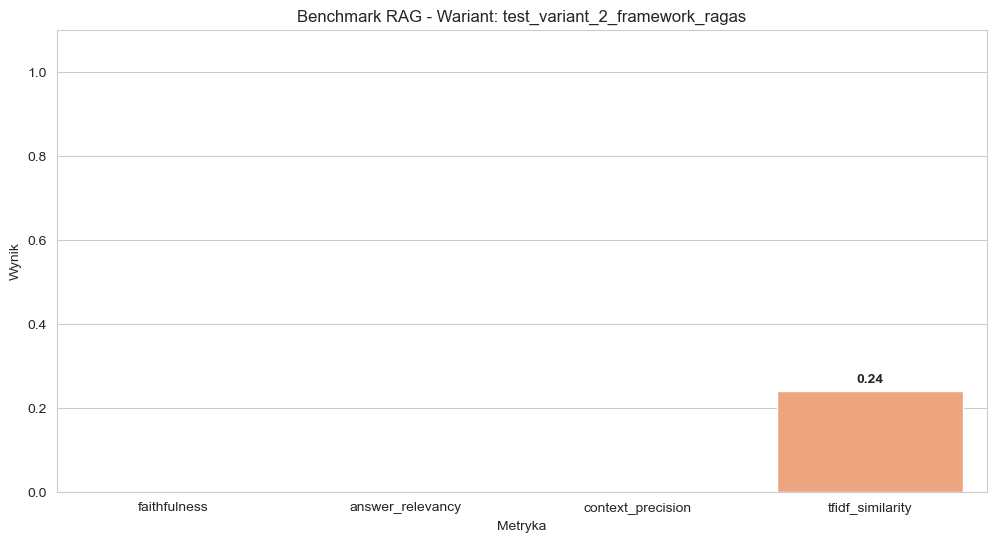


Wyniki końcowe:
   faithfulness  answer_relevancy  context_precision  tfidf_similarity
0           NaN               NaN                NaN          0.239914


In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ollama
import numpy as np
from datetime import datetime

# Ragas & Langchain
from ragas import EvaluationDataset, evaluate
from ragas.metrics import Faithfulness, AnswerRelevancy, ContextPrecision
# POPRAWIONE IMPORTY (naprawa Unresolved reference)
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from ragas.dataset_schema import SingleTurnSample

from langchain_ollama import ChatOllama, OllamaEmbeddings
from langchain_chroma import Chroma
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Scikit-learn
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

# === KONFIGURACJA ===
EMBEDDING_MODEL = 'qllama/bge-large-en-v1.5'
LANGUAGE_MODEL = 'hf.co/microsoft/Phi-3-mini-4k-instruct-gguf'
DOKUMENTY_PATH = "../dokumenty/txt"
DB_DIR = "../.././../wektorowa_bazadanych/lokalna" # Ścieżka z Twojego database.py
COLLECTION_NAME = "test_variant_2_framework_ragas" # Nowa nazwa dla testów wariantu

# 1. Inicjalizacja modeli
langchain_llm = ChatOllama(model=LANGUAGE_MODEL)
langchain_embeddings = OllamaEmbeddings(model=EMBEDDING_MODEL)

# Przygotowanie wrapperów dla Ragas
llm_judge = LangchainLLMWrapper(langchain_llm)
emb_judge = LangchainEmbeddingsWrapper(langchain_embeddings)

def prepare_vectorstore():
    """Ręczne przygotowanie bazy - tutaj możesz zmieniać parametry chunkowania"""
    print(f"--- Przygotowanie bazy w: {DB_DIR} ---")

    # 1. Ładowanie surowych plików TXT
    all_docs = []
    for file in os.listdir(DOKUMENTY_PATH):
        if file.endswith(".txt"):
            loader = TextLoader(os.path.join(DOKUMENTY_PATH, file), encoding="utf-8")
            all_docs.extend(loader.load())

    # 2. EKSPERYMENTALNY CHUNKING (Tutaj zmieniaj parametry do testów)
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=400,        # Rozmiar fragmentu
        chunk_overlap=40,      # Nakładka
        separators=["\n\n", "\n", ".", " "]
    )
    splits = text_splitter.split_documents(all_docs)
    print(f"Utworzono {len(splits)} fragmentów.")

    # 3. Inicjalizacja ChromaDB i dodanie dokumentów
    vectorstore = Chroma.from_documents(
        documents=splits,
        embedding=langchain_embeddings,
        persist_directory=DB_DIR,
        collection_name=COLLECTION_NAME
    )
    return vectorstore

def main():
    # KROK 1: Przygotowanie/Pobranie bazy
    # Możesz zakomentować prepare_vectorstore() i użyć Chroma(...) jeśli baza już istnieje
    vectorstore = prepare_vectorstore()

    # KROK 2: Proces RAG
    query = "Jakie ubezpieczenie uczelnia zaleca studentom?"
    print(f"\n🚀 Testowanie zapytania: {query}")

    # Wyszukiwanie (możesz testować k=1, k=3, k=5)
    retriever = vectorstore.as_retriever(search_kwargs={"k": 3})
    retrieved_docs = retriever.invoke(query)
    retrieved_contexts = [doc.page_content for doc in retrieved_docs]

    # Generowanie odpowiedzi
    context_combined = "\n".join(retrieved_contexts)
    prompt = f"""
    Jesteś asystentem odpowiadającym na podstawie KONTEKSTU.

    Zasady:
    - Odpowiadaj tylko na podstawie kontekstu
    - Jeśli brak informacji — napisz "Brak informacji w kontekście"
    - Odpowiedź ma być konkretna i po polsku

    Kontekst:
    {context_combined}

    Pytanie:
    {query}
    """

    response = ollama.chat(model=LANGUAGE_MODEL, messages=[{'role': 'user', 'content': prompt}])
    answer = response['message']['content']
    print(f"Odpowiedź modelu: {answer}")

    # --- KROK 3: Ewaluacja RAGAS (Nowe API) ---
    print("\n--- Ewaluacja RAGAS ---")
    from ragas.run_config import RunConfig
    sample = SingleTurnSample(
        user_input=query,
        response=answer,
        retrieved_contexts=retrieved_contexts,
        reference="§5. Uczelnia zaleca studentom posiadanie ubezpieczenia NNW (ubezpieczenie od następstw nieszczęśliwych wypadków)."
    )
    dataset = EvaluationDataset(samples=[sample])
    config = RunConfig(timeout=180, max_workers=1)

    result = evaluate(
    dataset=dataset,
    metrics=[
        Faithfulness(),
        AnswerRelevancy(),
        ContextPrecision()
    ],
    llm=llm_judge,
    embeddings=emb_judge,
    run_config = config
)
    df_res = result.to_pandas()

    # --- KROK 4: Dodatkowa analiza Sklearn (TF-IDF Similarity) ---
    vectorizer = TfidfVectorizer()
    # Porównujemy odpowiedź z połączonym kontekstem
    tfidf_matrix = vectorizer.fit_transform([answer, context_combined])
    similarity = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])[0][0]
    df_res['tfidf_similarity'] = similarity
    # df_res['faithfulness', 'answer_relevancy', 'context_precision'] = similarity

    # --- KROK 5: Wizualizacja ---
    # Upewniamy się, że nazwy kolumn w df_res zgadzają się z metrics_cols
    # Ragas czasem zwraca nazwy z małych liter, sprawdzamy to:
    print("Dostępne kolumny w wynikach:", df_res.columns.tolist())

    metrics_cols = ['faithfulness', 'answer_relevancy', 'context_precision', 'tfidf_similarity']

    # Filtrujemy tylko te kolumny, które faktycznie istnieją w df_res
    existing_cols = [c for c in metrics_cols if c in df_res.columns]

    plt.figure(figsize=(12, 6))
    sns.set_style("whitegrid")

    plot_data = df_res[existing_cols].melt()
    plot_data.columns = ['Metryka', 'Wynik']

    sns.barplot(data=plot_data, x='Metryka', y='Wynik', palette="magma")
    plt.ylim(0, 1.1)
    plt.title(f"Benchmark RAG - Wariant: {COLLECTION_NAME}")

    # Dodanie etykiet nad słupkami
    for i, v in enumerate(df_res[existing_cols].iloc[0]):
        plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')

    plt.show()
    print("\nWyniki końcowe:")
    print(df_res[metrics_cols])

if __name__ == "__main__":
    main()